In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler # onehot encoding и стандартизации
from sklearn.model_selection import cross_val_score

%config InlineBackend.figure_format = 'retina'
sns.set_palette('gist_earth')

import warnings
warnings.filterwarnings("ignore")

In [ ]:
PATH_TO_ENGINEERED_DATA = "data/aggregated/20250624/engineered_features_with_odds.csv"
PATH_TO_FIGHTERS_DATA = "data/processed/20250623/cleaned_fighters.csv"

In [2]:
data = pd.read_csv("./" + PATH_TO_ENGINEERED_DATA)
fighters_data = pd.read_csv("./" + PATH_TO_FIGHTERS_DATA)

In [3]:
data = data.sort_values('event_date')

In [4]:
# subsetting only data that is known at the time of each fight (and 'result' as a target variable)

data_model = data[[
        'event_date',
        'result',
        'weight_class',
        'belt',
        'height_fighter',
        'reach_fighter',
        'stance_fighter',
        'sex_fighter',
        'country_fighter',
        'stance_opp',
        'country_opp',
        'age_fighter',
        'cum_total_fights_fighter',
        'cum_wins_fighter',
        'cum_losses_fighter',
        'perc_fights_won_fighter',
        'perc_fights_lost_fighter',
        'method_DQ_wins_fighter',
        'method_DQ_losses_fighter',
        'method_KO_TKO_wins_fighter',
        'method_KO_TKO_losses_fighter',
        'method_M_DEC_wins_fighter',
        'method_M_DEC_losses_fighter',
        'method_SUB_wins_fighter',
        'method_SUB_losses_fighter',
        'method_S_DEC_wins_fighter',
        'method_S_DEC_losses_fighter',
        'method_U_DEC_wins_fighter',
        'method_U_DEC_losses_fighter',
        'winning_streak_fighter',
        'losing_streak_fighter',
        'prev_result_fighter',
        'kd_fighter_mean',
        'str_fighter_mean',
        'str_total_fighter_mean',
        'td_fighter_mean',
        'td_total_fighter_mean',
        'sub_fighter_mean',
        'revs_fighter_mean',
        'time_control_perc_fighter_mean',
        'slpm_fighter_mean',
        'str_acc_fighter_mean',
        'sapm_fighter_mean',
        'str_def_fighter_mean',
        'td_avg_fighter_mean',
        'td_acc_fighter_mean',
        'td_def_fighter_mean',
        'sub_avg_fighter_mean',
        'mean_rounds_fighter',
        'belt_cum_if_won_fighter',
        'perf_cum_if_won_fighter',
        'fight_cum_if_won_fighter',
        'ko_cum_if_won_fighter',
        'sub_cum_if_won_fighter',
        'cum_total_fights_opp',
        'cum_wins_opp',
        'cum_losses_opp',
        'perc_fights_won_opp',
        'perc_fights_lost_opp',
        'method_DQ_wins_opp',
        'method_DQ_losses_opp',
        'method_KO_TKO_wins_opp',
        'method_KO_TKO_losses_opp',
        'method_M_DEC_wins_opp',
        'method_M_DEC_losses_opp',
        'method_SUB_wins_opp',
        'method_SUB_losses_opp',
        'method_S_DEC_wins_opp',
        'method_S_DEC_losses_opp',
        'method_U_DEC_wins_opp',
        'method_U_DEC_losses_opp',
        'winning_streak_opp',
        'losing_streak_opp',
        'prev_result_opp',
        'kd_opp_mean',
        'str_opp_mean',
        'str_total_opp_mean',
        'td_opp_mean',
        'td_total_opp_mean',
        'sub_opp_mean',
        'revs_opp_mean',
        'time_control_perc_opp_mean',
        'slpm_opp_mean',
        'str_acc_opp_mean',
        'sapm_opp_mean',
        'str_def_opp_mean',
        'td_avg_opp_mean',
        'td_acc_opp_mean',
        'td_def_opp_mean',
        'sub_avg_opp_mean',
        'mean_rounds_opp',
        'belt_cum_if_won_opp',
        'perf_cum_if_won_opp',
        'fight_cum_if_won_opp',
        'ko_cum_if_won_opp',
        'sub_cum_if_won_opp',
        'age_diff',
        'height_diff',
        'reach_diff',
        'cum_total_fights_diff',
        'cum_wins_diff',
        'cum_losses_diff',
        'perc_fights_won_diff',
        'perc_fights_lost_diff',
        'winning_streak_diff',
        'losing_streak_diff',
        'mean_rounds_diff',
        'belt_cum_if_won_diff',
        'kd_mean_diff',
        'str_mean_diff',
        'str_total_mean_diff',
        'td_mean_diff',
        'td_total_mean_diff',
        'sub_mean_diff',
        'revs_mean_diff',
        'time_control_perc_mean_diff',
        'slpm_mean_diff',
        'str_acc_mean_diff',
        'sapm_mean_diff',
        'str_def_mean_diff',
        'td_avg_mean_diff',
        'td_acc_mean_diff',
        'td_def_mean_diff',
        'sub_avg_mean_diff',
        'fighter_odd', # WOP - uncomment if data with odds
        'opponent_odd', # WOP - uncomment if data with odds
]].copy()

In [5]:
int64_cols = [
        'result',
        'height_fighter',
        'reach_fighter',
        'sex_fighter',
        'age_fighter',
        'cum_total_fights_fighter',
        'cum_wins_fighter',
        'cum_losses_fighter',
        'method_DQ_wins_fighter',
        'method_DQ_losses_fighter',
        'method_KO_TKO_wins_fighter',
        'method_KO_TKO_losses_fighter',
        'method_M_DEC_wins_fighter',
        'method_M_DEC_losses_fighter',
        'method_SUB_wins_fighter',
        'method_SUB_losses_fighter',
        'method_S_DEC_wins_fighter',
        'method_S_DEC_losses_fighter',
        'method_U_DEC_wins_fighter',
        'method_U_DEC_losses_fighter',
        'winning_streak_fighter',
        'losing_streak_fighter',
        'prev_result_fighter',
        'belt_cum_if_won_fighter',
        'perf_cum_if_won_fighter',
        'fight_cum_if_won_fighter',
        'ko_cum_if_won_fighter',
        'sub_cum_if_won_fighter',
        'cum_total_fights_opp',
        'cum_wins_opp',
        'cum_losses_opp',
        'method_DQ_wins_opp',
        'method_DQ_losses_opp',
        'method_KO_TKO_wins_opp',
        'method_KO_TKO_losses_opp',
        'method_M_DEC_wins_opp',
        'method_M_DEC_losses_opp',
        'method_SUB_wins_opp',
        'method_SUB_losses_opp',
        'method_S_DEC_wins_opp',
        'method_S_DEC_losses_opp',
        'method_U_DEC_wins_opp',
        'method_U_DEC_losses_opp',
        'winning_streak_opp',
        'losing_streak_opp',
        'prev_result_opp',
        'belt_cum_if_won_opp',
        'perf_cum_if_won_opp',
        'fight_cum_if_won_opp',
        'ko_cum_if_won_opp',
        'sub_cum_if_won_opp',
        'age_diff',
        'height_diff',
        'reach_diff',
        'cum_total_fights_diff',
        'cum_wins_diff',
        'cum_losses_diff',
        'winning_streak_diff',
        'losing_streak_diff',
        'belt_cum_if_won_diff'
]

float64_cols = [
        'perc_fights_won_fighter',
        'perc_fights_lost_fighter',
        'kd_fighter_mean',
        'str_fighter_mean',
        'str_total_fighter_mean',
        'td_fighter_mean',
        'td_total_fighter_mean',
        'sub_fighter_mean',
        'revs_fighter_mean',
        'time_control_perc_fighter_mean',
        'slpm_fighter_mean',
        'str_acc_fighter_mean',
        'sapm_fighter_mean',
        'str_def_fighter_mean',
        'td_avg_fighter_mean',
        'td_acc_fighter_mean',
        'td_def_fighter_mean',
        'sub_avg_fighter_mean',
        'mean_rounds_fighter',
        'perc_fights_won_opp',
        'perc_fights_lost_opp',
        'kd_opp_mean',
        'str_opp_mean',
        'str_total_opp_mean',
        'td_opp_mean',
        'td_total_opp_mean',
        'sub_opp_mean',
        'revs_opp_mean',
        'time_control_perc_opp_mean',
        'slpm_opp_mean',
        'str_acc_opp_mean',
        'sapm_opp_mean',
        'str_def_opp_mean',
        'td_avg_opp_mean',
        'td_acc_opp_mean',
        'td_def_opp_mean',
        'sub_avg_opp_mean',
        'mean_rounds_opp',
        'perc_fights_won_diff',
        'perc_fights_lost_diff',
        'mean_rounds_diff',
        'kd_mean_diff',
        'str_mean_diff',
        'str_total_mean_diff',
        'td_mean_diff',
        'td_total_mean_diff',
        'sub_mean_diff',
        'revs_mean_diff',
        'time_control_perc_mean_diff',
        'slpm_mean_diff',
        'str_acc_mean_diff',
        'sapm_mean_diff',
        'str_def_mean_diff',
        'td_avg_mean_diff',
        'td_acc_mean_diff',
        'td_def_mean_diff',
        'sub_avg_mean_diff',
        'fighter_odd', # WOP - uncomment if data with odds
        'opponent_odd', # WOP - uncomment if data with odds
]

In [6]:
data_model[int64_cols] = data_model[int64_cols].astype('int64')
data_model[float64_cols] = data_model[float64_cols].astype(float)

In [7]:
# selecting male or female fighters - currently not distinguishing

data_model = data_model.drop(columns = ['sex_fighter', 'weight_class', 'event_date'])

In [8]:
# train and test split based on fighters, not the fights itself - better for avoiding hidden dataleaks

names_train, names_test = train_test_split(fighters_data['fighter_name'], test_size=0.10, shuffle = True)

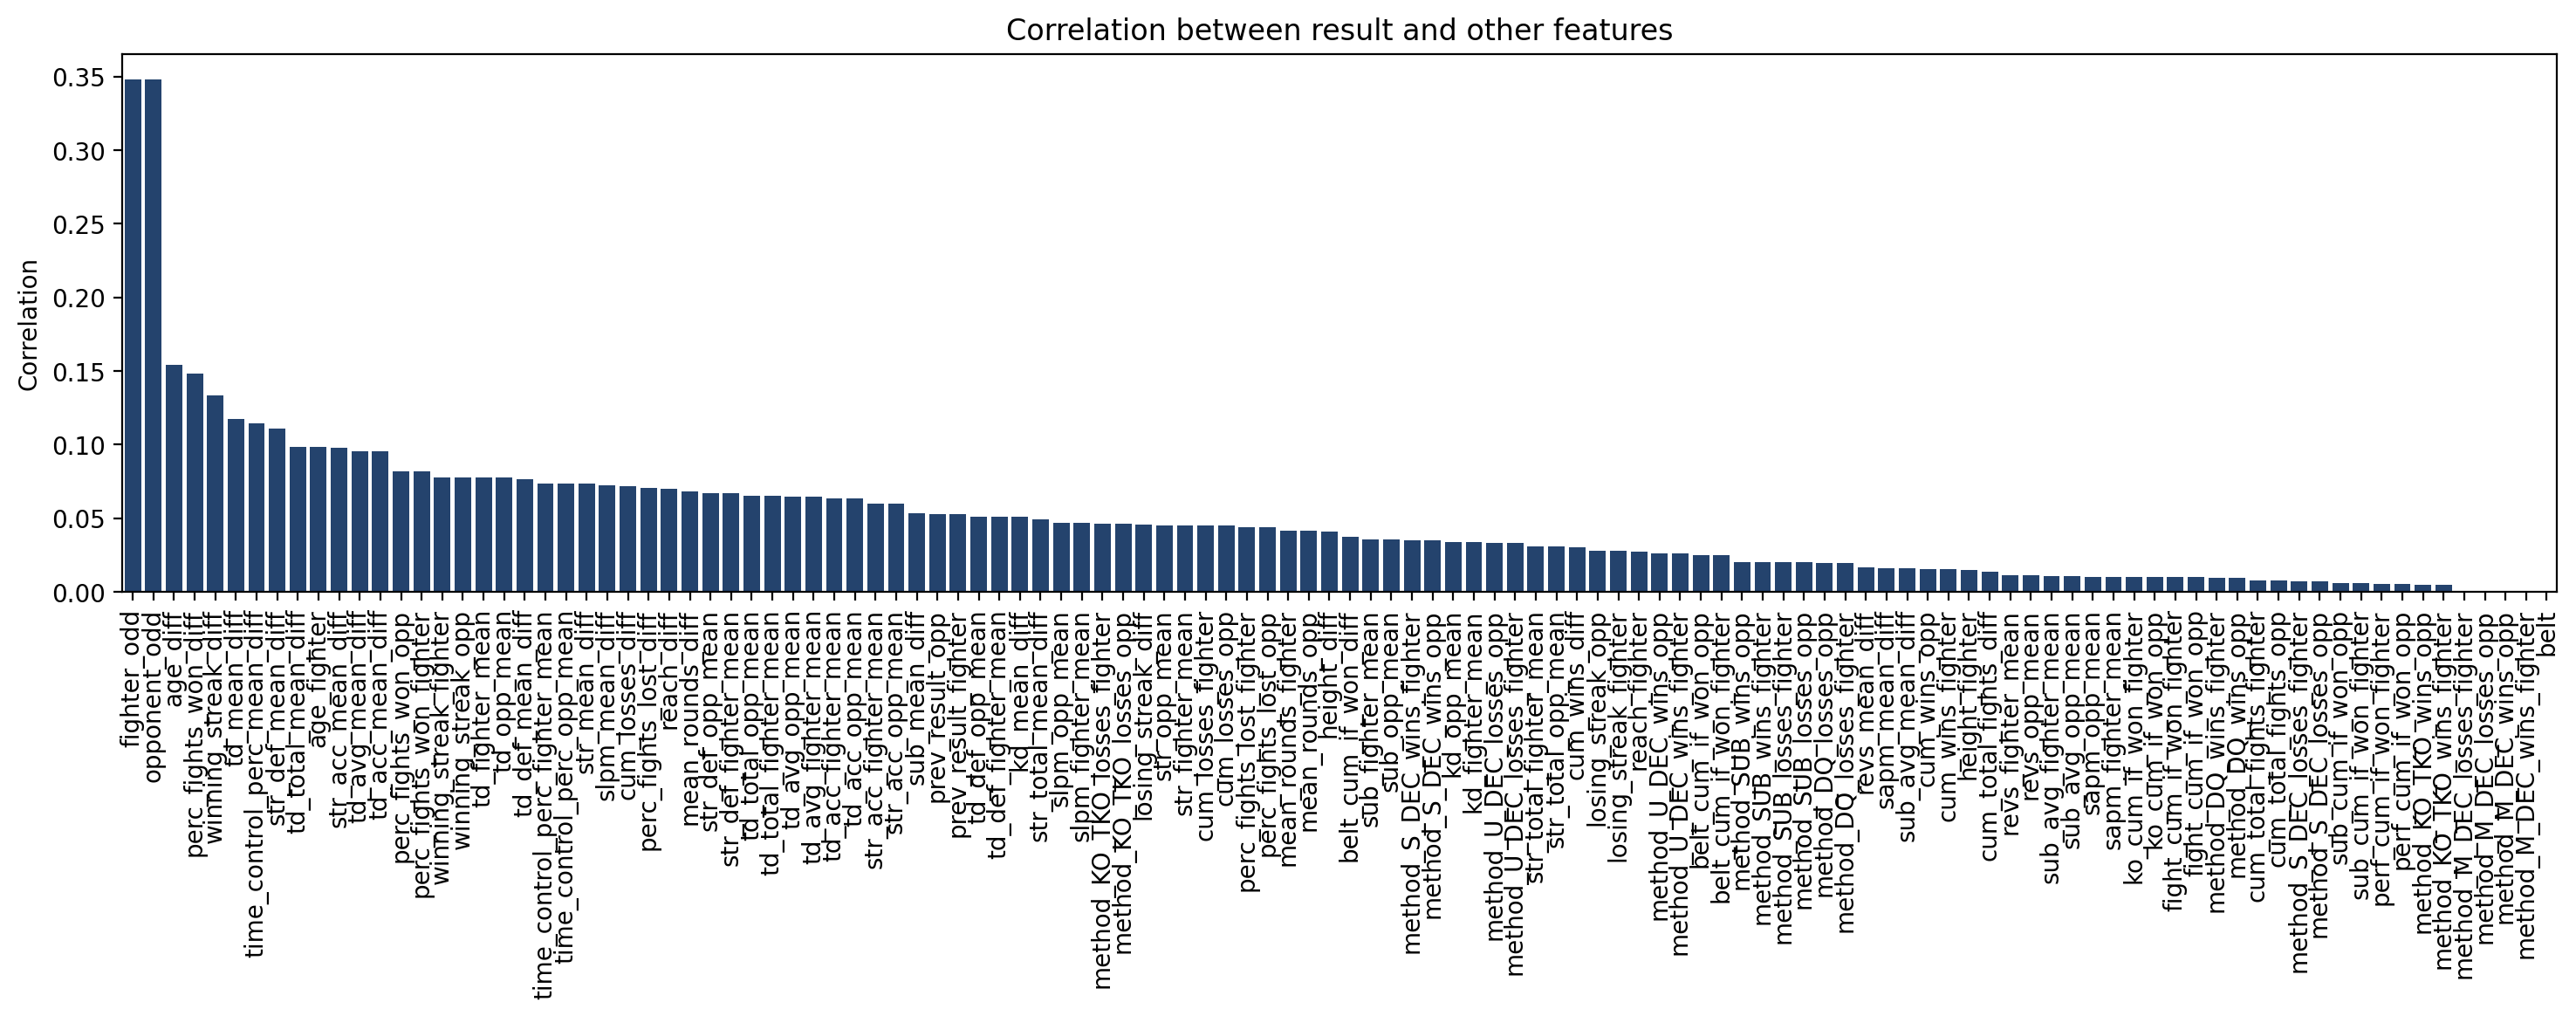

In [9]:
# plotting correlations with 'result'

fig, axes = plt.subplots(figsize=(18, 4));
sns.barplot(data_model.corr(numeric_only=True)['result'].abs().sort_values(ascending = False)[1:]);
axes.tick_params('x', labelrotation=90)
axes.set_title('Correlation between result and other features');
axes.set_ylabel('Correlation');

In [10]:
X = data_model.drop('result', axis = 1)
y = data_model['result']

In [11]:
# train - include all fights where names (fighter AND opp) appear in names_train
# test - include all fights where names (fighter OR opp) appear in names_test

train_index = data.fighter_name.isin(names_train) * data.opp_name.isin(names_train)
test_index = data.fighter_name.isin(names_test) + data.opp_name.isin(names_test)

In [12]:
X_train = X[train_index]
y_train = y[train_index]
X_test = X[test_index]
y_test = y[test_index]

In [14]:
# selecting feature columns, numerical and category columns

feature_cols = [
        'height_fighter',
        'reach_fighter',
        'stance_fighter',
        'country_fighter',
        'stance_opp',
        'country_opp',
        'age_fighter',
        # 'age_diff', # leaving this out because of multicollinearity
        # 'height_diff', # leaving this out because of multicollinearity
        # 'reach_diff', # leaving this out because of multicollinearity
        'cum_total_fights_fighter',
        'cum_wins_fighter',
        'cum_losses_fighter',
        'perc_fights_won_fighter',
        'perc_fights_lost_fighter',
        'method_DQ_wins_fighter',
        'method_DQ_losses_fighter',
        'method_KO_TKO_wins_fighter',
        'method_KO_TKO_losses_fighter',
        'method_M_DEC_wins_fighter',
        'method_M_DEC_losses_fighter',
        'method_SUB_wins_fighter',
        'method_SUB_losses_fighter',
        'method_S_DEC_wins_fighter',
        'method_S_DEC_losses_fighter',
        'method_U_DEC_wins_fighter',
        'method_U_DEC_losses_fighter',
        'winning_streak_fighter',
        'losing_streak_fighter',
        'prev_result_fighter',
        'kd_fighter_mean',
        'str_fighter_mean',
        'str_total_fighter_mean',
        'td_fighter_mean',
        'td_total_fighter_mean',
        'sub_fighter_mean',
        'revs_fighter_mean',
        'time_control_perc_fighter_mean',
        'slpm_fighter_mean',
        'str_acc_fighter_mean',
        'sapm_fighter_mean',
        'str_def_fighter_mean',
        'td_avg_fighter_mean',
        'td_acc_fighter_mean',
        'td_def_fighter_mean',
        'sub_avg_fighter_mean',
        'mean_rounds_fighter',
        'belt_cum_if_won_fighter',
        'perf_cum_if_won_fighter',
        'fight_cum_if_won_fighter',
        'ko_cum_if_won_fighter',
        'sub_cum_if_won_fighter',
        'cum_total_fights_opp',
        'cum_wins_opp',
        'cum_losses_opp',
        'perc_fights_won_opp',
        'perc_fights_lost_opp',
        'method_DQ_wins_opp',
        'method_DQ_losses_opp',
        'method_KO_TKO_wins_opp',
        'method_KO_TKO_losses_opp',
        'method_M_DEC_wins_opp',
        'method_M_DEC_losses_opp',
        'method_SUB_wins_opp',
        'method_SUB_losses_opp',
        'method_S_DEC_wins_opp',
        'method_S_DEC_losses_opp',
        'method_U_DEC_wins_opp',
        'method_U_DEC_losses_opp',
        'winning_streak_opp',
        'losing_streak_opp',
        'prev_result_opp',
        'kd_opp_mean',
        'str_opp_mean',
        'str_total_opp_mean',
        'td_opp_mean',
        'td_total_opp_mean',
        'sub_opp_mean',
        'revs_opp_mean',
        'time_control_perc_opp_mean',
        'slpm_opp_mean',
        'str_acc_opp_mean',
        'sapm_opp_mean',
        'str_def_opp_mean',
        'td_avg_opp_mean',
        'td_acc_opp_mean',
        'td_def_opp_mean',
        'sub_avg_opp_mean',
        'mean_rounds_opp',
        'belt_cum_if_won_opp',
        'perf_cum_if_won_opp',
        'fight_cum_if_won_opp',
        'ko_cum_if_won_opp',
        'sub_cum_if_won_opp',
        'age_diff',
        'height_diff',
        'reach_diff',
        'cum_total_fights_diff',
        'cum_wins_diff',
        'cum_losses_diff',
        'perc_fights_won_diff',
        'perc_fights_lost_diff',
        'winning_streak_diff',
        'losing_streak_diff',
        'mean_rounds_diff',
        'belt_cum_if_won_diff',
        'kd_mean_diff',
        'str_mean_diff',
        'str_total_mean_diff',
        'td_mean_diff',
        'td_total_mean_diff',
        'sub_mean_diff',
        'revs_mean_diff',
        'time_control_perc_mean_diff',
        'slpm_mean_diff',
        'str_acc_mean_diff',
        'sapm_mean_diff',
        'str_def_mean_diff',
        'td_avg_mean_diff',
        'td_acc_mean_diff',
        'td_def_mean_diff',
        'sub_avg_mean_diff',
        'fighter_odd',
        'opponent_odd',
]

cat_cols = [
        'stance_fighter',
        'country_fighter',
        'stance_opp',
        'country_opp'
]

num_cols = [item for item in feature_cols if item not in cat_cols]

In [15]:
# creating pool datasets for catboost

from catboost import CatBoostClassifier, Pool, cv
from sklearn.metrics import accuracy_score

# full dataset for cross validation
dataset = Pool(data=X[feature_cols],
                     label=y,
                     cat_features=cat_cols,
                    )

train_dataset = Pool(data=X_train[feature_cols],
                     label=y_train,
                     cat_features=cat_cols,
                    )

test_dataset = Pool(data=X_test[feature_cols],
                     # label=y_test,
                     cat_features=cat_cols)

In [16]:
%%time

# running catboost 'out of the box'

params = {
'loss_function' : 'Logloss',
'verbose' : True,
'eval_metric': 'Accuracy',
}

model = CatBoostClassifier(**params) 

model.fit(train_dataset) 

train_y_pred = model.predict(train_dataset)
test_y_pred = model.predict(test_dataset)
test_y_pred_proba = model.predict_proba(test_dataset)[:,1]

Learning rate set to 0.029949
0:	learn: 0.6526454	total: 209ms	remaining: 3m 28s
1:	learn: 0.6519882	total: 265ms	remaining: 2m 12s
2:	learn: 0.6519060	total: 316ms	remaining: 1m 45s
3:	learn: 0.6514131	total: 371ms	remaining: 1m 32s
4:	learn: 0.6520703	total: 436ms	remaining: 1m 26s
5:	learn: 0.6543707	total: 506ms	remaining: 1m 23s
6:	learn: 0.6539599	total: 565ms	remaining: 1m 20s
7:	learn: 0.6524811	total: 625ms	remaining: 1m 17s
8:	learn: 0.6534670	total: 684ms	remaining: 1m 15s
9:	learn: 0.6528097	total: 739ms	remaining: 1m 13s
10:	learn: 0.6538778	total: 807ms	remaining: 1m 12s
11:	learn: 0.6551922	total: 846ms	remaining: 1m 9s
12:	learn: 0.6568354	total: 900ms	remaining: 1m 8s
13:	learn: 0.6568354	total: 959ms	remaining: 1m 7s
14:	learn: 0.6562603	total: 1.02s	remaining: 1m 6s
15:	learn: 0.6569175	total: 1.08s	remaining: 1m 6s
16:	learn: 0.6564246	total: 1.14s	remaining: 1m 5s
17:	learn: 0.6578212	total: 1.2s	remaining: 1m 5s
18:	learn: 0.6568354	total: 1.26s	remaining: 1m 4s
1

In [17]:
# roc-auc score

from sklearn.metrics import roc_curve, roc_auc_score

test_auc = roc_auc_score(y_test.tolist(), test_y_pred_proba)
print(f'ROC-AUC test: {test_auc:.5f}')

ROC-AUC test: 0.71429


In [18]:
# accuracies scores on train and test

accuracy_train = accuracy_score(y_train, train_y_pred)
accuracy_test = accuracy_score(y_test.tolist(), test_y_pred)
print(f'Accuracy train: {accuracy_train:.5f}')
print(f'Accuracy test: {accuracy_test:.5f}')

Accuracy train: 0.81696
Accuracy test: 0.66133


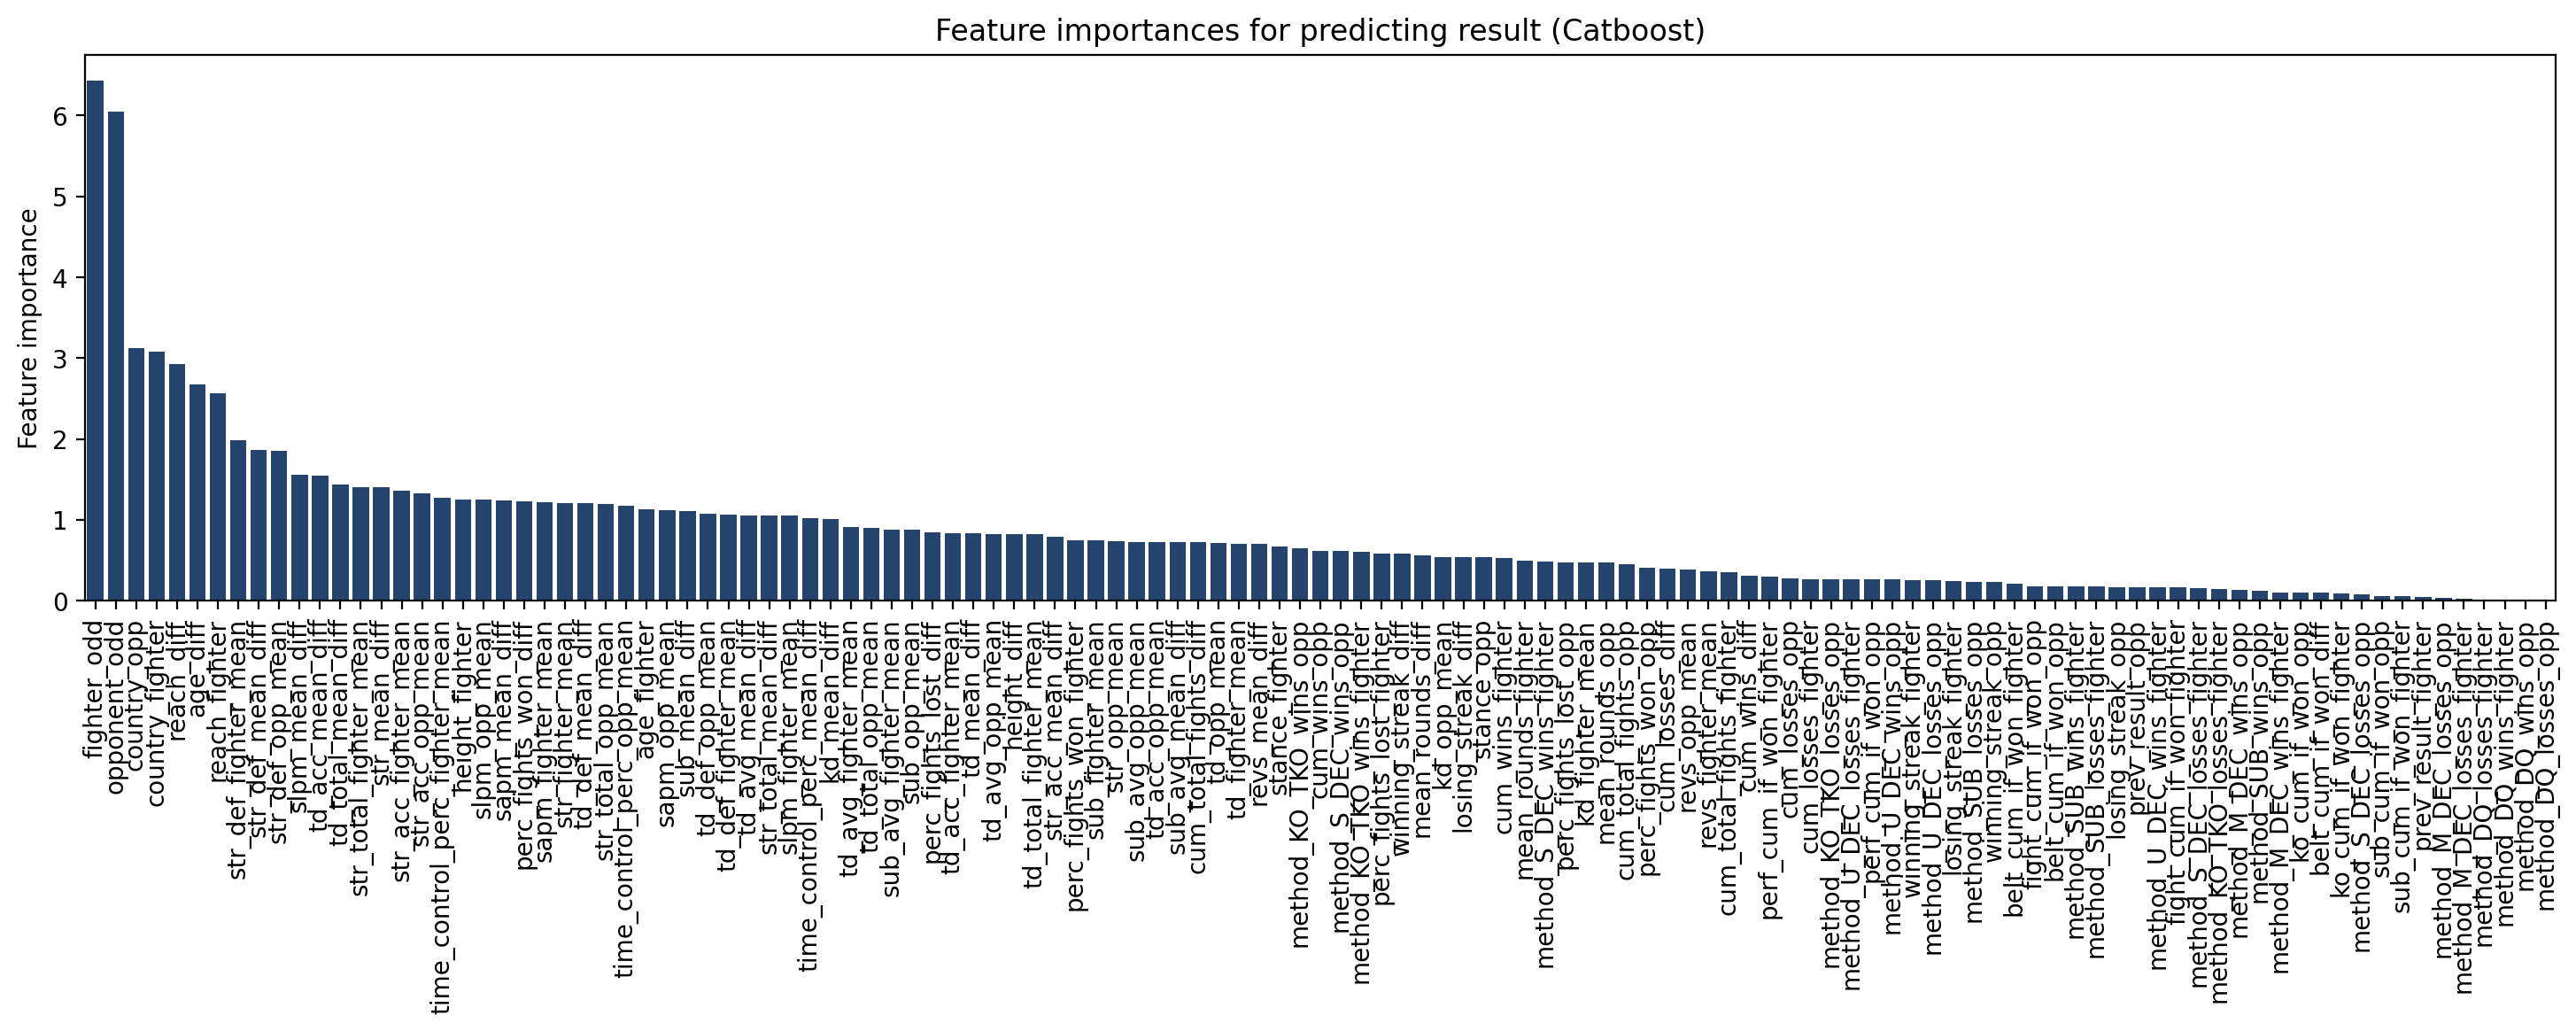

In [19]:
# plotting feature importances

fig, axes = plt.subplots(figsize=(18, 4));
sns.barplot(pd.DataFrame({'FI': model.feature_importances_}, index = train_dataset.get_feature_names()).sort_values('FI', ascending = False)['FI']);
axes.tick_params('x', labelrotation=90)
axes.set_title('Feature importances for predicting result (Catboost)');
axes.set_ylabel('Feature importance');

In [20]:
df1 = data_model[test_index]
df1.reset_index(drop=True, inplace=True)
df2 = pd.DataFrame(test_y_pred)
df2.reset_index(drop=True, inplace=True)

pd.concat([df1, df2], axis = 1)

,result,belt,height_fighter,reach_fighter,stance_fighter,country_fighter,stance_opp,country_opp,age_fighter,cum_total_fights_fighter,...,str_acc_mean_diff,sapm_mean_diff,str_def_mean_diff,td_avg_mean_diff,td_acc_mean_diff,td_def_mean_diff,sub_avg_mean_diff,fighter_odd,opponent_odd,0
0,0,0,193,183,Orthodox,Not_Found,Orthodox,United_States,35,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300.0,-420.0,0
1,1,0,193,201,Orthodox,United_States,Orthodox,Not_Found,30,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-420.0,300.0,1
2,0,0,172,183,Orthodox,United_States,Orthodox,France,29,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-110.0,-110.0,0
3,1,0,182,183,Orthodox,United_States,Orthodox,Italy,35,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-260.0,220.0,1
4,0,0,182,183,Orthodox,Italy,Orthodox,United_States,26,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,220.0,-260.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,0,0,175,178,Orthodox,Brazil,Southpaw,United_States,32,5,...,0.045730,2.280354,-0.005036,-0.470219,-0.333333,-0.477778,-0.817439,300.0,-380.0,0
2494,1,0,177,175,Southpaw,United_States,Orthodox,Brazil,31,3,...,-0.045730,-2.280354,0.005036,0.470219,0.333333,0.477778,0.817439,-380.0,300.0,1
2495,1,0,193,203,Orthodox,United_States,Orthodox,Not_Found,34,18,...,0.485064,4.012943,0.567483,3.661457,0.365406,0.100427,0.000000,-250.0,175.0,1
2496,0,0,193,193,Orthodox,Not_Found,Orthodox,United_States,33,0,...,-0.485064,-4.012943,-0.567483,-3.661457,-0.365406,-0.100427,0.000000,175.0,-250.0,0


### Performing Time Series cross-valiation with Catboost

In [21]:
%%time

# performing Time Series cross-valiation with Catboost

params = {
    'iterations': 1000,       # Number of boosting iterations
    'loss_function': 'Logloss',  # For multi-class classification
    'eval_metric': 'Accuracy',       # Evaluation metric
    'verbose': True
}

cv_results = cv(
    params=params,
    pool=dataset,
    fold_count=5,               # Number of folds (e.g., 5-fold CV)
    type = 'TimeSeries', 
    # partition_random_seed=42,   # Seed for reproducibility
    # shuffle=True,               # Shuffle data before cross-validation
    # stratified=True,            # Stratify folds by class label
    verbose=False               # Set to True to see progress
)

# Display the CV results
cv_results

Training on fold [0/5]

bestTest = 0.6714461286
bestIteration = 526

Training on fold [1/5]

bestTest = 0.6648914379
bestIteration = 337

Training on fold [2/5]

bestTest = 0.6362146661
bestIteration = 261

Training on fold [3/5]

bestTest = 0.6685784515
bestIteration = 199

Training on fold [4/5]

bestTest = 0.669807456
bestIteration = 532

CPU times: total: 31min 17s
Wall time: 3min 56s


,iterations,test-Accuracy-mean,test-Accuracy-std,train-Accuracy-mean,train-Accuracy-std,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std
0,0,0.641622,0.015490,0.656717,0.012545,0.689908,0.000249,0.689116,0.000487
1,1,0.642605,0.017356,0.661297,0.013505,0.686781,0.000744,0.685417,0.000571
2,2,0.645801,0.017006,0.660325,0.011195,0.683632,0.000969,0.681691,0.000889
3,3,0.645309,0.017280,0.659335,0.010238,0.680979,0.001334,0.678511,0.001441
4,4,0.645965,0.019509,0.659936,0.009957,0.678179,0.001738,0.675146,0.001718
...,...,...,...,...,...,...,...,...,...
995,995,0.648341,0.015828,0.895591,0.060239,0.627270,0.017429,0.358122,0.101244
996,996,0.648505,0.015919,0.895571,0.060388,0.627264,0.017418,0.357947,0.101213
997,997,0.648259,0.016156,0.895587,0.060300,0.627273,0.017444,0.357843,0.101239
998,998,0.648177,0.016321,0.895745,0.060335,0.627311,0.017453,0.357650,0.101251


In [22]:
mean_accuracy = cv_results['test-Accuracy-mean'].max()
print(f'Mean Accuracy: {mean_accuracy:.5f}')

Mean Accuracy: 0.65801


### Performing grid search with time series cross validation

In [23]:
%%time

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder

# need to encode categorical data first to feed it to GridSearchCV

X = data_model.drop('result', axis = 1)
y = data_model['result']

cat_data = X[cat_cols]
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(cat_data)
codes = enc.transform(cat_data).toarray().astype(np.int64)
feature_names = enc.get_feature_names_out(cat_data.columns)
X = pd.concat([X[num_cols],
               pd.DataFrame(codes, columns = feature_names)], axis=1)

model_params = {
'loss_function' : 'Logloss',
'verbose' : True,
'eval_metric': 'Accuracy',
}

# Define the model
model = CatBoostClassifier(**model_params)

# Define the parameter grid
param_grid = {
    'iterations': [50, 100, 1000],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5]
}

# Define the time series cross-validator
tscv = TimeSeriesSplit(n_splits=5)

# Set up GridSearchCV with the TimeSeriesSplit cross-validator
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',  # Adjust scoring based on your needs
    n_jobs=-1                          # Use all available cores
)

# Run the grid search
grid_search.fit(X, y)

0:	learn: 0.6506213	total: 18.1ms	remaining: 18s
1:	learn: 0.6516455	total: 35.5ms	remaining: 17.7s
2:	learn: 0.6511676	total: 50.8ms	remaining: 16.9s
3:	learn: 0.6521234	total: 67.8ms	remaining: 16.9s
4:	learn: 0.6515089	total: 82.5ms	remaining: 16.4s
5:	learn: 0.6519869	total: 97.7ms	remaining: 16.2s
6:	learn: 0.6513724	total: 113ms	remaining: 16.1s
7:	learn: 0.6510310	total: 127ms	remaining: 15.8s
8:	learn: 0.6519869	total: 143ms	remaining: 15.7s
9:	learn: 0.6523283	total: 158ms	remaining: 15.6s
10:	learn: 0.6514407	total: 173ms	remaining: 15.5s
11:	learn: 0.6518503	total: 187ms	remaining: 15.4s
12:	learn: 0.6512358	total: 204ms	remaining: 15.5s
13:	learn: 0.6508944	total: 220ms	remaining: 15.5s
14:	learn: 0.6517138	total: 234ms	remaining: 15.3s
15:	learn: 0.6514407	total: 247ms	remaining: 15.2s
16:	learn: 0.6513724	total: 263ms	remaining: 15.2s
17:	learn: 0.6511676	total: 277ms	remaining: 15.1s
18:	learn: 0.6519186	total: 291ms	remaining: 15s
19:	learn: 0.6510993	total: 306ms	remai

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=<catboost.core.CatBoostClassifier object at 0x000002E0AE275190>,
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [50, 100, 1000],
                         'l2_leaf_reg': [1, 3, 5],
                         'learning_rate': [0.01, 0.1, 0.2]},
             scoring='accuracy')

In [24]:
# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
Best score: 0.65710774272839


### Performing Optuna search with time series cross validation

In [25]:
from sklearn.metrics import accuracy_score
import optuna

In [26]:
%%time

X = data_model.drop('result', axis = 1)
y = data_model['result']

# The objective function is where you define the model and parameter search space for Optuna. Within the function, you’ll:
# Sample hyperparameters with trial.suggest_* methods.
# Use TimeSeriesSplit for cross-validation.
# Train and evaluate the model on each fold, then return the average validation error (e.g., RMSE).

def objective(trial):
    # Define the hyperparameter search space
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 1, 255),
        'loss_function': 'Logloss',
        'eval_metric': 'Accuracy'
    }

    # Set up time series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []

    for train_index, valid_index in tscv.split(X):
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

        # Create Pool for training and validation with categorical feature specification
        train_pool = Pool(data=X_train, label=y_train, cat_features=cat_cols)
        valid_pool = Pool(data=X_valid, label=y_valid, cat_features=cat_cols)

        # Create and train the CatBoost model
        model = CatBoostClassifier(**params, verbose=0)
        model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

        # Predict and calculate accuracy
        preds = model.predict(valid_pool)
        accuracy = accuracy_score(y_valid, preds)
        cv_scores.append(accuracy)

    # Return the mean accuracy across folds
    return np.mean(cv_scores)

# Create the study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # You can set n_trials to control the number of trials

[I 2025-06-24 14:56:34,825] A new study created in memory with name: no-name-7fef550d-5f4d-45d5-80fe-4e96f84ab493
[I 2025-06-24 14:56:46,042] Trial 0 finished with value: 0.655714870954527 and parameters: {'iterations': 761, 'depth': 4, 'learning_rate': 0.22604280532349927, 'l2_leaf_reg': 1.4676849363407856, 'random_strength': 1.544782246702973e-07, 'bagging_temperature': 0.43544478717469237, 'border_count': 92}. Best is trial 0 with value: 0.655714870954527.
[I 2025-06-24 14:57:06,552] Trial 1 finished with value: 0.6537484637443671 and parameters: {'iterations': 630, 'depth': 7, 'learning_rate': 0.11047069966081031, 'l2_leaf_reg': 0.39824050964511654, 'random_strength': 3.768942092600051e-05, 'bagging_temperature': 0.544480673485185, 'border_count': 176}. Best is trial 0 with value: 0.655714870954527.
[I 2025-06-24 14:57:19,661] Trial 2 finished with value: 0.6579270790659566 and parameters: {'iterations': 245, 'depth': 4, 'learning_rate': 0.1786546026957826, 'l2_leaf_reg': 7.3160982

CPU times: total: 1h 40min 10s
Wall time: 18min 6s


In [27]:
print("Best parameters:", study.best_params)
print("Best accuracy:", '%.5f' % study.best_value)

Best parameters: {'iterations': 240, 'depth': 4, 'learning_rate': 0.04322046742437349, 'l2_leaf_reg': 4.475232844213949, 'random_strength': 0.00022986963304624645, 'bagging_temperature': 0.41741167540920165, 'border_count': 152}
Best accuracy: 0.66055


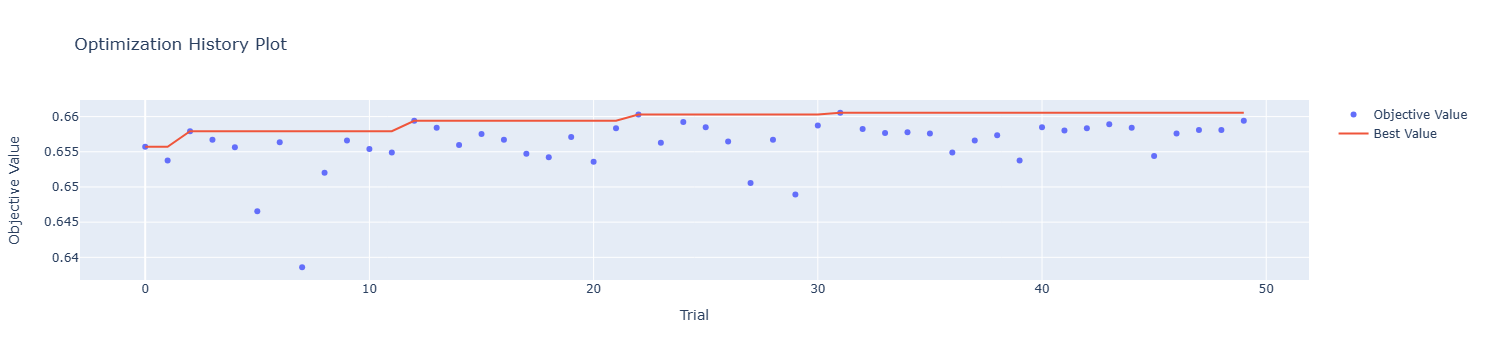

In [28]:
# Import visualization modules
from optuna.visualization import plot_optimization_history, plot_param_importances

# Plot optimization history
plot_optimization_history(study)

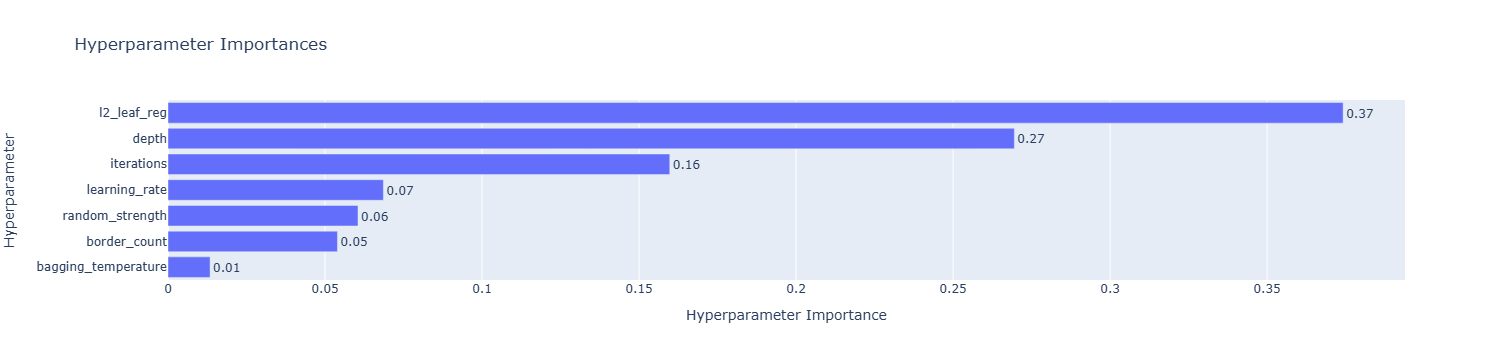

In [29]:
# Plot parameter importances
plot_param_importances(study)

### Apply optimal parameters to train/test

In [30]:
study.best_params

{'iterations': 240,
 'depth': 4,
 'learning_rate': 0.04322046742437349,
 'l2_leaf_reg': 4.475232844213949,
 'random_strength': 0.00022986963304624645,
 'bagging_temperature': 0.41741167540920165,
 'border_count': 152}

In [31]:
%%time

# running catboost with optimal parameters

params = {
'loss_function' : 'Logloss',
'verbose' : True,
'eval_metric': 'Accuracy',
}

best_params = study.best_params

model = CatBoostClassifier(**params, **best_params) 

model.fit(train_dataset) 

train_y_pred = model.predict(train_dataset)
test_y_pred = model.predict(test_dataset)
test_y_pred_proba = model.predict_proba(test_dataset)[:,1]

0:	learn: 0.6528097	total: 43.1ms	remaining: 10.3s
1:	learn: 0.6529740	total: 86ms	remaining: 10.2s
2:	learn: 0.6529740	total: 128ms	remaining: 10.1s
3:	learn: 0.6523168	total: 170ms	remaining: 10s
4:	learn: 0.6530562	total: 214ms	remaining: 10.1s
5:	learn: 0.6533848	total: 255ms	remaining: 9.95s
6:	learn: 0.6528097	total: 293ms	remaining: 9.76s
7:	learn: 0.6531384	total: 342ms	remaining: 9.91s
8:	learn: 0.6531384	total: 417ms	remaining: 10.7s
9:	learn: 0.6528097	total: 463ms	remaining: 10.7s
10:	learn: 0.6526454	total: 514ms	remaining: 10.7s
11:	learn: 0.6529740	total: 558ms	remaining: 10.6s
12:	learn: 0.6520703	total: 603ms	remaining: 10.5s
13:	learn: 0.6522346	total: 645ms	remaining: 10.4s
14:	learn: 0.6529740	total: 687ms	remaining: 10.3s
15:	learn: 0.6533848	total: 731ms	remaining: 10.2s
16:	learn: 0.6528919	total: 774ms	remaining: 10.2s
17:	learn: 0.6529740	total: 817ms	remaining: 10.1s
18:	learn: 0.6527276	total: 858ms	remaining: 9.98s
19:	learn: 0.6526454	total: 899ms	remaining

In [32]:
# roc-auc score

test_auc = roc_auc_score(y_test.tolist(), test_y_pred_proba)
print(f'ROC-AUC test: {test_auc:.5f}')

ROC-AUC test: 0.71376


In [33]:
# accuracies scores on train and test

accuracy_train = accuracy_score(y_train, train_y_pred)
accuracy_test = accuracy_score(y_test.tolist(), test_y_pred)
print(f'Accuracy train: {accuracy_train:.5f}')
print(f'Accuracy test: {accuracy_test:.5f}')

Accuracy train: 0.69060
Accuracy test: 0.66173


### Use Random Forest to get feature importances

In [34]:
# running random forest for comparison

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train[num_cols], y_train)

print(f'Accuracy of Random Forest classifier: {accuracy_score(y_test.tolist(), rf.predict(X_test[num_cols])):.5f}')

Accuracy of Random Forest classifier: 0.64371


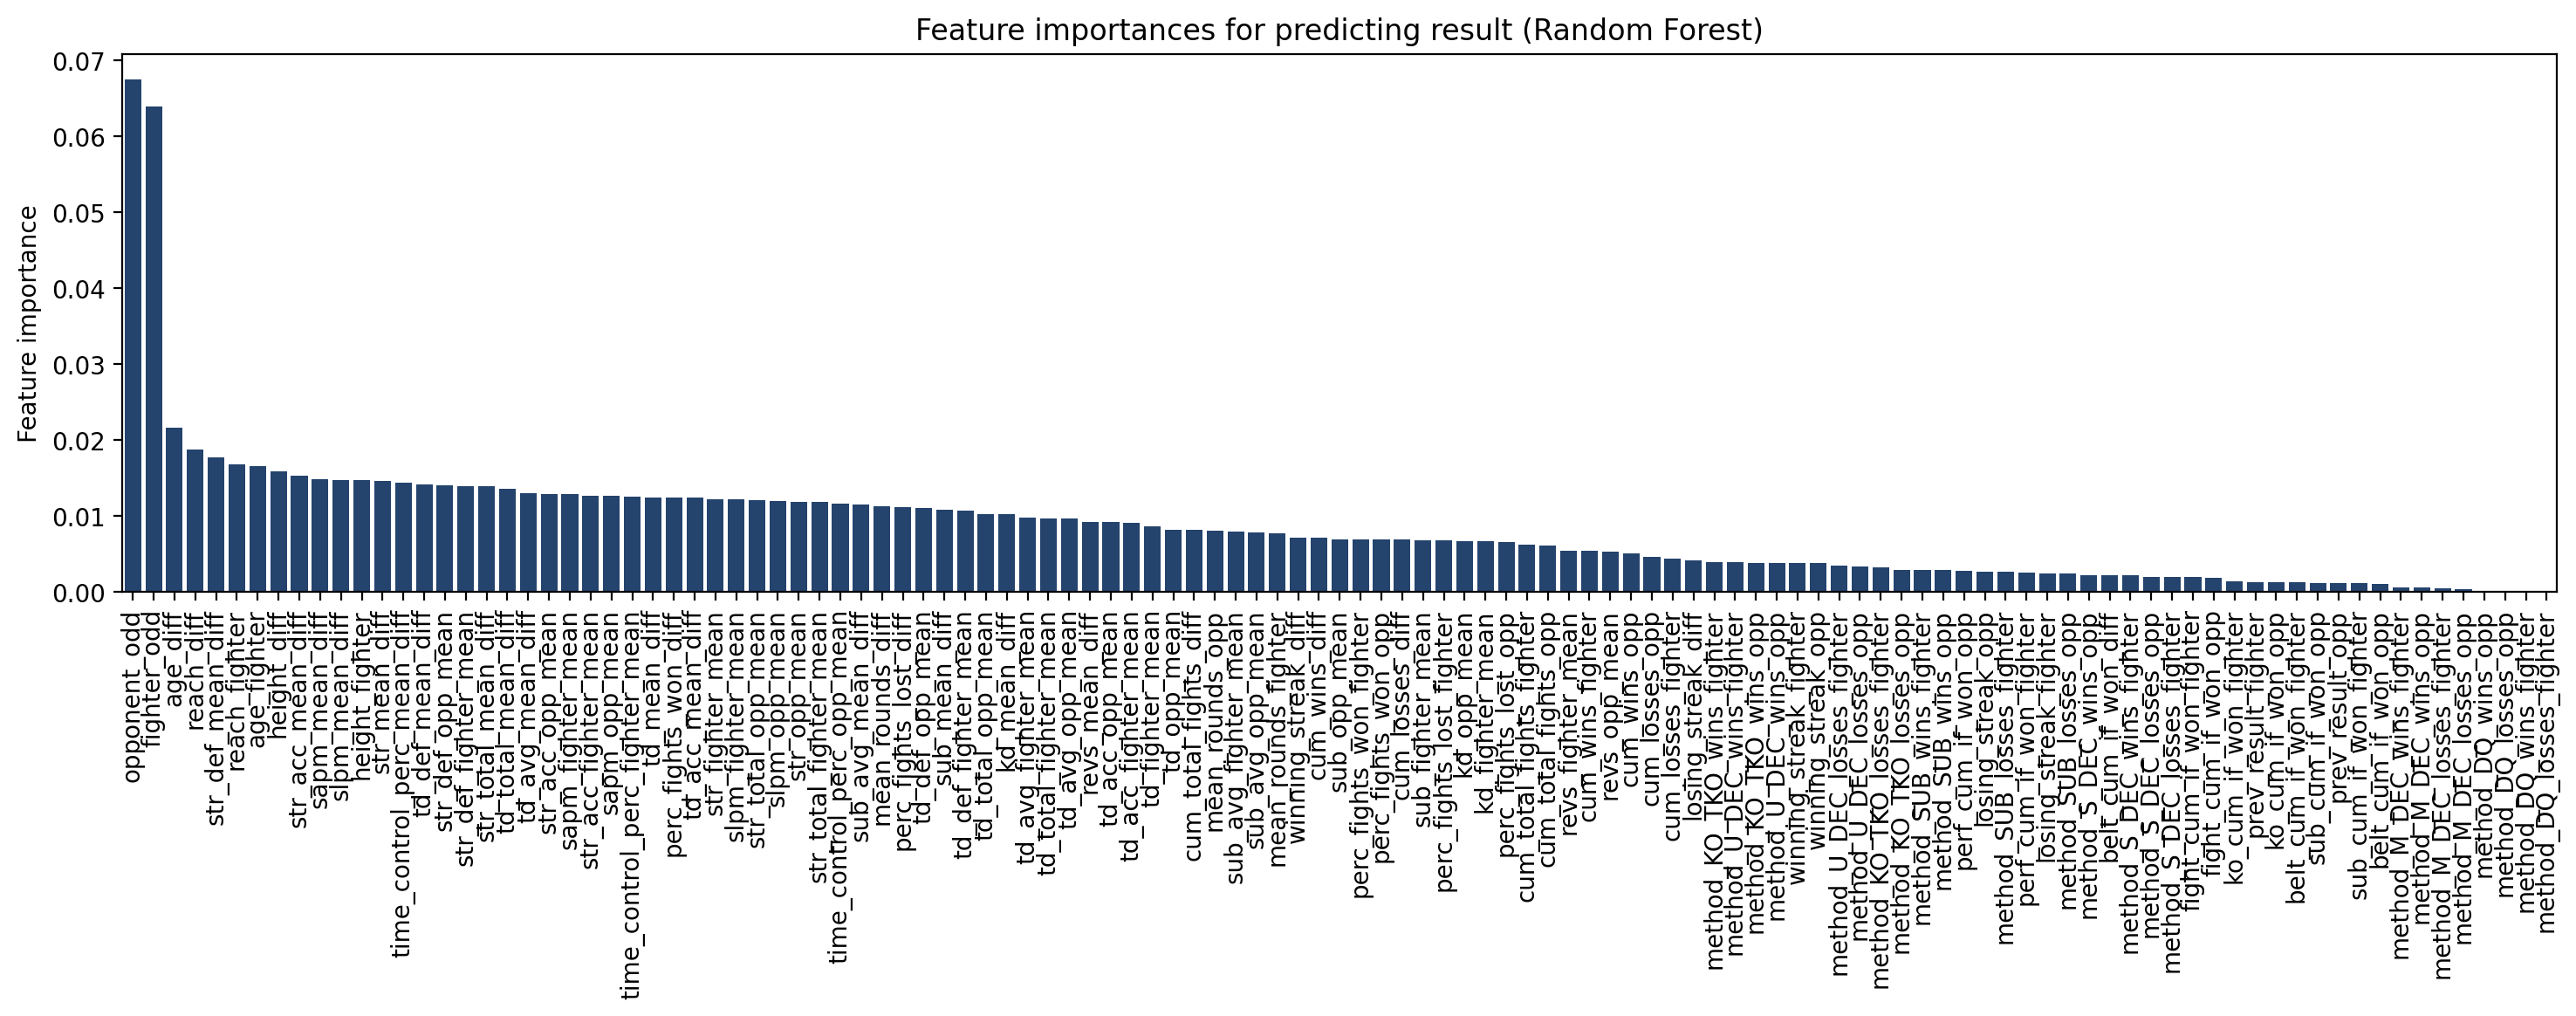

In [35]:
# plotting feature importances according to random forest

fig, axes = plt.subplots(figsize=(18, 4));
sns.barplot(pd.DataFrame({'FI': rf.feature_importances_}, index = num_cols).sort_values('FI', ascending = False)['FI']);
axes.tick_params('x', labelrotation=90)
axes.set_title('Feature importances for predicting result (Random Forest)');
axes.set_ylabel('Feature importance');